<a href="https://colab.research.google.com/github/hemant-gautam-student/Android-Projects/blob/main/OD_EndSem_231008003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless scikit-image ultralytics torchmetrics matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.0 MB/s eta 0:00:00


In [25]:
from google.colab import files
uploaded = files.upload()


Saving img2.jpg to img2 (5).jpg
Saving animal.jpg to animal (5).jpg
Saving animal1.jpg to animal1 (4).jpg
Saving animal2.jpg to animal2.jpg
Saving animal3.jpg to animal3 (3).jpg
Saving img1.jpg to img1 (5).jpg


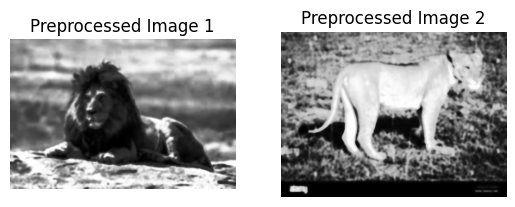

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read images
img1 = cv2.imread('img1.jpg')
img2 = cv2.imread('img2.jpg')

# Function for preprocessing
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    contrast = cv2.equalizeHist(blur)
    return contrast

# Apply preprocessing
p1 = preprocess(img1)
p2 = preprocess(img2)

# Display results
plt.subplot(1,2,1)
plt.imshow(p1, cmap='gray')
plt.title("Preprocessed Image 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(p2, cmap='gray')
plt.title("Preprocessed Image 2")
plt.axis('off')

plt.show()

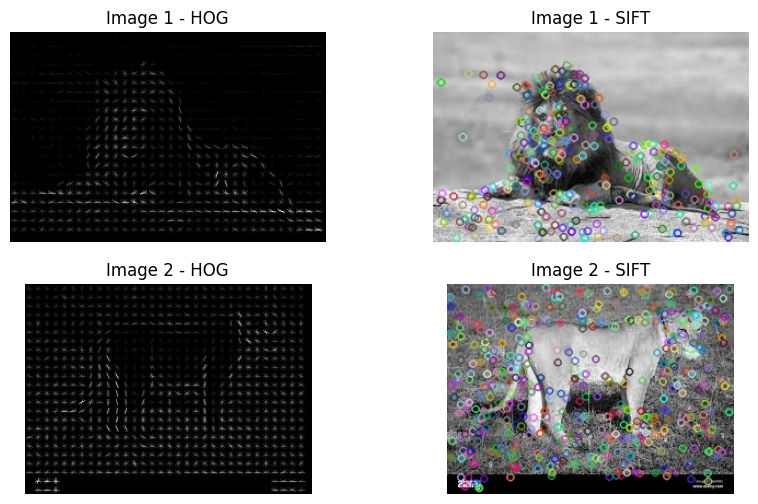

In [ ]:
from skimage.feature import hog
from skimage import exposure
import cv2
import matplotlib.pyplot as plt

# Read images (grayscale)
img1 = cv2.imread('img1.jpg', 0)
img2 = cv2.imread('img2.jpg', 0)

# SIFT
sift = cv2.SIFT_create()

def extract_features(img):
    # HOG
    fd, hog_img = hog(img, visualize=True)
    hog_img = exposure.rescale_intensity(hog_img)

    # SIFT
    kp, des = sift.detectAndCompute(img, None)
    sift_img = cv2.drawKeypoints(img, kp, None)

    return hog_img, sift_img

# Process both images
hog1, sift1 = extract_features(img1)
hog2, sift2 = extract_features(img2)

# Display results
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.imshow(hog1, cmap='gray')
plt.title("Image 1 - HOG")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(sift1, cmap='gray')
plt.title("Image 1 - SIFT")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(hog2, cmap='gray')
plt.title("Image 2 - HOG")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(sift2, cmap='gray')
plt.title("Image 2 - SIFT")
plt.axis('off')

plt.show()

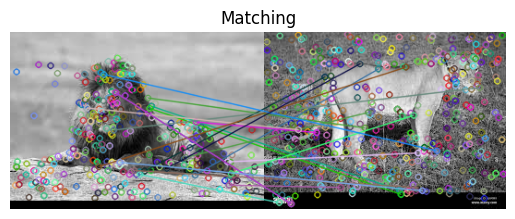

In [ ]:
img2 = cv2.imread('img2.jpg', 0)

kp2, des2 = sift.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

match_img = cv2.drawMatches(gray, kp1, img2, kp2, matches[:20], None)

plt.imshow(match_img)
plt.title("Matching")
plt.axis('off')
plt.show()


0: 352x640 1 giraffe, 127.2ms
Speed: 3.2ms preprocess, 127.2ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)


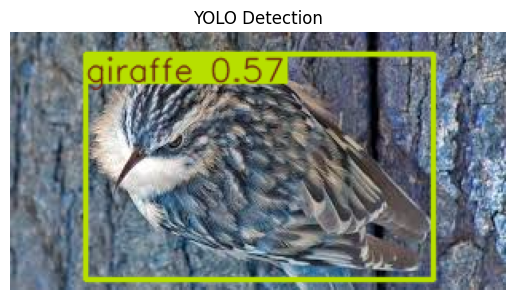

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

img3 = cv2.imread("animal1.jpg")
results = model(img3)

res_img = results[0].plot()

plt.imshow(res_img)
plt.title("YOLO Detection")
plt.axis('off')
plt.show()


0: 640x480 1 cat, 182.7ms
Speed: 6.1ms preprocess, 182.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


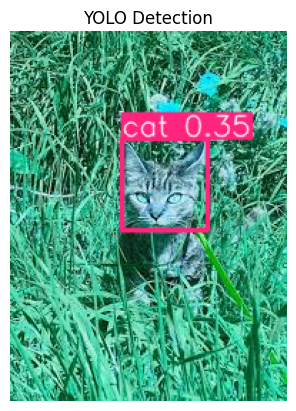

In [47]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

img3 = cv2.imread("animal2.jpg")
results = model(img3)

res_img = results[0].plot()

plt.imshow(res_img)
plt.title("YOLO Detection")
plt.axis('off')
plt.show()


0: 448x640 (no detections), 155.2ms
Speed: 4.2ms preprocess, 155.2ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


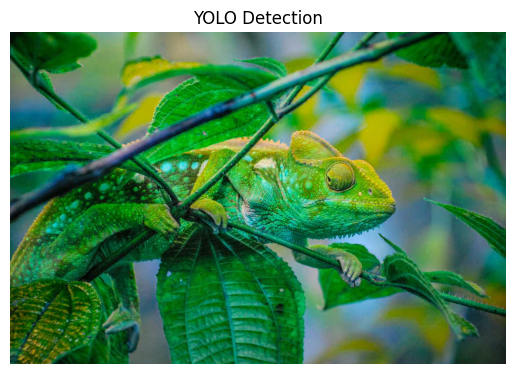

In [29]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

img3 = cv2.imread("animal.jpg")
results = model(img3)

res_img = results[0].plot()

plt.imshow(res_img)
plt.title("YOLO Detection")
plt.axis('off')
plt.show()


===== Evaluation Metrics =====
IoU        : 0.6965
Threshold  : 0.5
Precision  : 1.0000
Recall     : 1.0000
F1 Score   : 1.0000



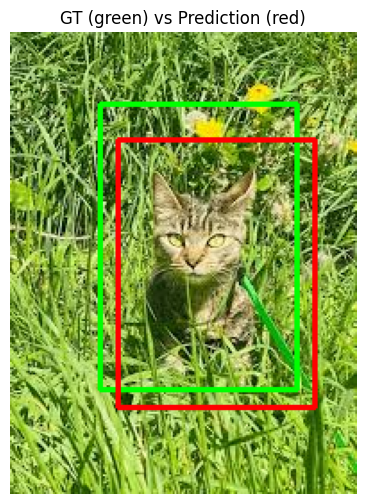

In [46]:
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ---- 1. Load image ----
image_path = "animal2.jpg"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image not found!")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ---- 2. Boxes ----
gt_box = [50, 40, 160, 200]
pred_box = [60, 60, 170, 210]

# ---- 3. IoU function ----
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = areaA + areaB - inter_area
    return inter_area / union if union != 0 else 0.0

# ---- 4. Compute IoU ----
iou = compute_iou(gt_box, pred_box)

# ---- 5. Classification-style metrics ----
iou_threshold = 0.5

y_true = [1]
y_pred = [1 if iou >= iou_threshold else 0]

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# ---- 6. Print formatted metrics ----
print("\n===== Evaluation Metrics =====")
print(f"IoU        : {iou:.4f}")
print(f"Threshold  : {iou_threshold}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print("=============================\n")

# ---- 7. Draw only boxes (no text clutter) ----
output = image.copy()

cv2.rectangle(output, (gt_box[0], gt_box[1]), (gt_box[2], gt_box[3]), (0,255,0), 2)
cv2.rectangle(output, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (255,0,0), 2)

# ---- 8. Show image ----
plt.figure(figsize=(5,6))
plt.imshow(output)
plt.axis('off')
plt.title("GT (green) vs Prediction (red)")
plt.show()